In [1]:
import os
FM100_DATA_DIR = r"/mnt/c/Users/zevaz/OneDrive/Escritorio/Metamers/FM100data"

print("Looking in:", FM100_DATA_DIR)
print("Files:", os.listdir(FM100_DATA_DIR))


Looking in: /mnt/c/Users/zevaz/OneDrive/Escritorio/Metamers/FM100data
Files: ['AllFM100results.csv', 'MET025.txt', 'MET025b.txt', 'MET030.txt', 'MET037a.txt', 'MET038a.txt', 'MET038b.txt', 'MET039.txt', 'MET039b.txt', 'MET040a.txt', 'MET040b.txt', 'MET041.txt', 'MET042.txt', 'MET043.txt', 'MET044.txt', 'MET045.txt', 'MET046.txt', 'partINFO.csv', 'PDdata.txt', 'repeatedSessions.txt', 'repeatedSessionsPY.txt', 'scoresALL.csv', 'scoresHC_CVD_PR_DE.csv', 'scoresPD.csv']


In [3]:
from metamers.scores.FM100 import (
    load_FM100_raw,
    load_participant_info,
    identify_participant,
    FM100_TESwhole,
    compute_VKS_metrics,
    compute_PES,
    compute_TES_trays
)

import pandas as pd

# Load data
FM100 = load_FM100_raw()
info = load_participant_info()

# Process only first 5 participants
subset = FM100.iloc[:5]

results = []

for idx, row in subset.iterrows():

    # --- Extract ID and cap order ---
    raw_id = row.iloc[3]                 # column 3 = Reference
    caps   = row.iloc[16:101].to_numpy() # 85 caps

    # --- Identify participant ---
    meta = identify_participant(raw_id, info)

    # --- Compute TES ---
    TES, SRTES, err_vals = FM100_TESwhole(caps)

    # --- Compute VKS metrics ---
    vks = compute_VKS_metrics(caps)

    # --- Compute PES ---
    pes = compute_PES(caps)

    # --- Compute tray-level TES ---
    trays = compute_TES_trays(caps)

    # --- Collect everything into one dict ---
    results.append({
        "ValidID": meta["ValidID"],
        "Session": meta["Session"],
        "Group": meta["Group"],
        "Subgroup": meta["Subgroup"],
        "TES": TES,
        "SqrtTES": SRTES,
        "VKS_Angle": vks["Angle"],
        "VKS_MajRad": vks["MajRad"],
        "VKS_MinRad": vks["MinRad"],
        "VKS_Sindex": vks["Sindex"],
        "VKS_Cindex": vks["Cindex"],
        "PES_RG": pes["PES_RG"],
        "PES_BY": pes["PES_BY"],
        "PES_RG_sqrt": pes["PES_RG_sqrt"],
        "PES_BY_sqrt": pes["PES_BY_sqrt"],
        "TES_tray1": trays["TES_tray"][0],
        "TES_tray2": trays["TES_tray"][1],
        "TES_tray3": trays["TES_tray"][2],
        "TES_tray4": trays["TES_tray"][3],
        "TES_whole_from_trays": trays["TES_whole"]
    })

# Convert to DataFrame for easy viewing
df_results = pd.DataFrame(results)


In [17]:
from metamers.scores.FM100 import load_FM100_raw, load_participant_info
from metamers.scores.plotting import extract_error_profile
from metamers.scores.plotting import plot_group_errors, plot_group_errors_lims
from metamers.scores.plotting import plot_population_comparison, plot_population_comparison_shading


FM100 = load_FM100_raw()
info  = load_participant_info()

exclude = ["MET020"]
info = info[~info["SubID"].isin(exclude)]
info_PDCTR = info[info["Group"].isin(["CTR", "PD"])]

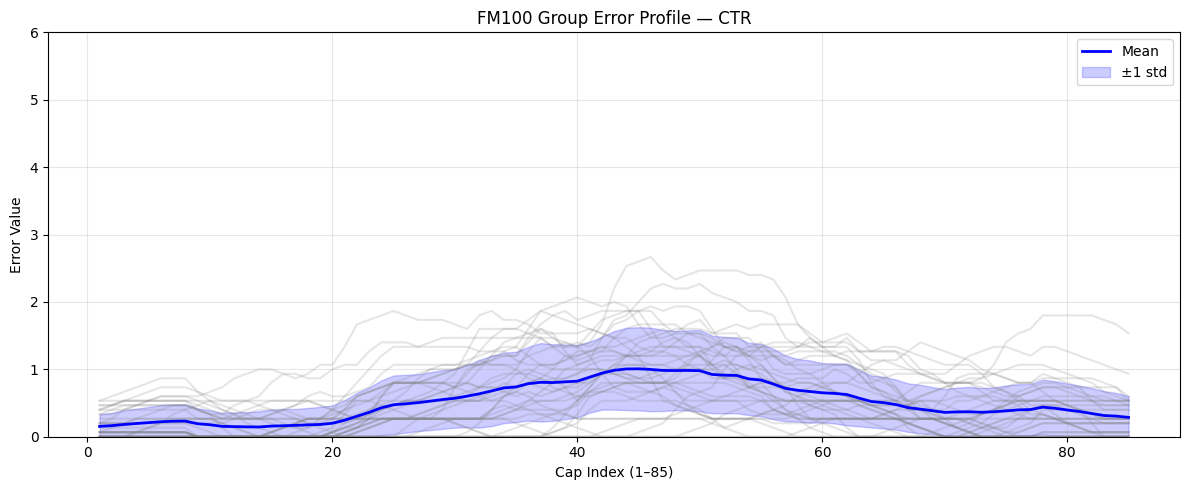

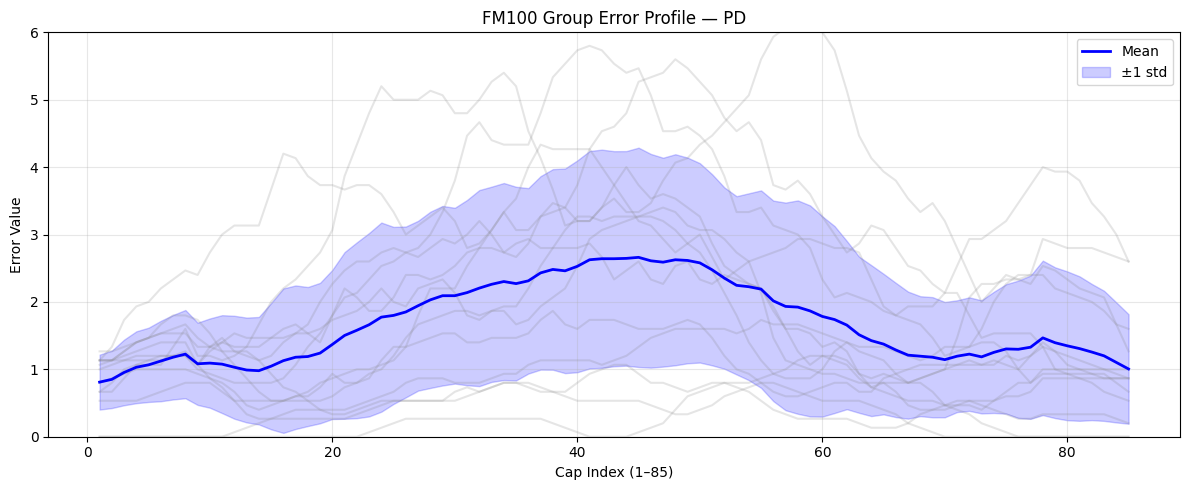

In [18]:
plot_group_errors_lims(FM100, info, group_name="CTR", ymin=0,ymax=6, show_individuals=True)
plot_group_errors_lims(FM100, info, group_name="PD", ymin=0,ymax=6, show_individuals=True)


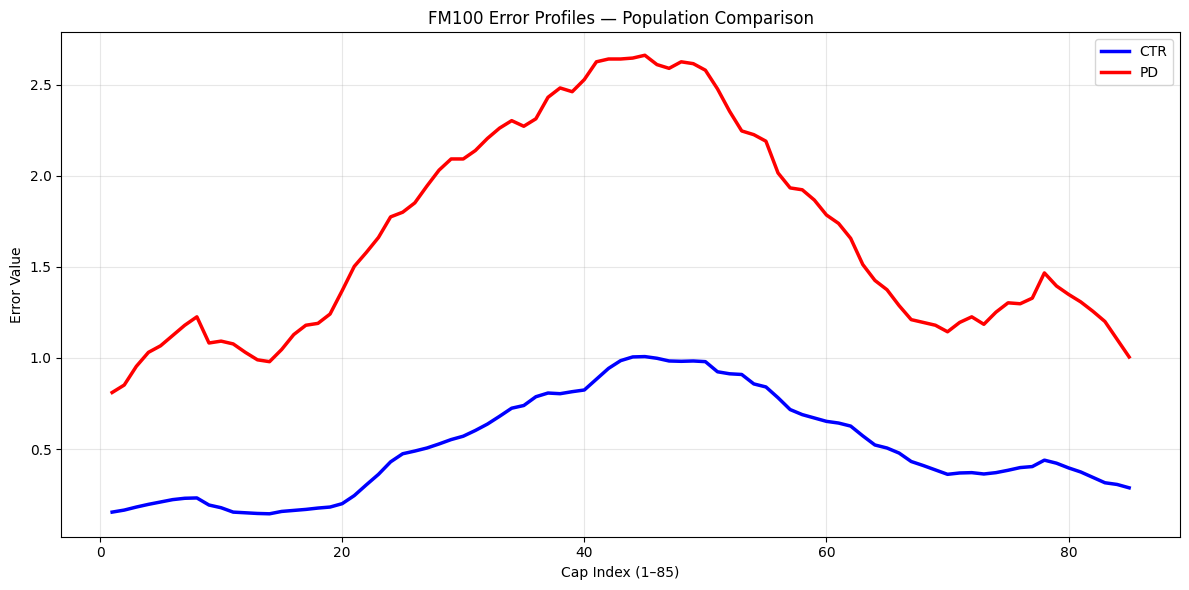

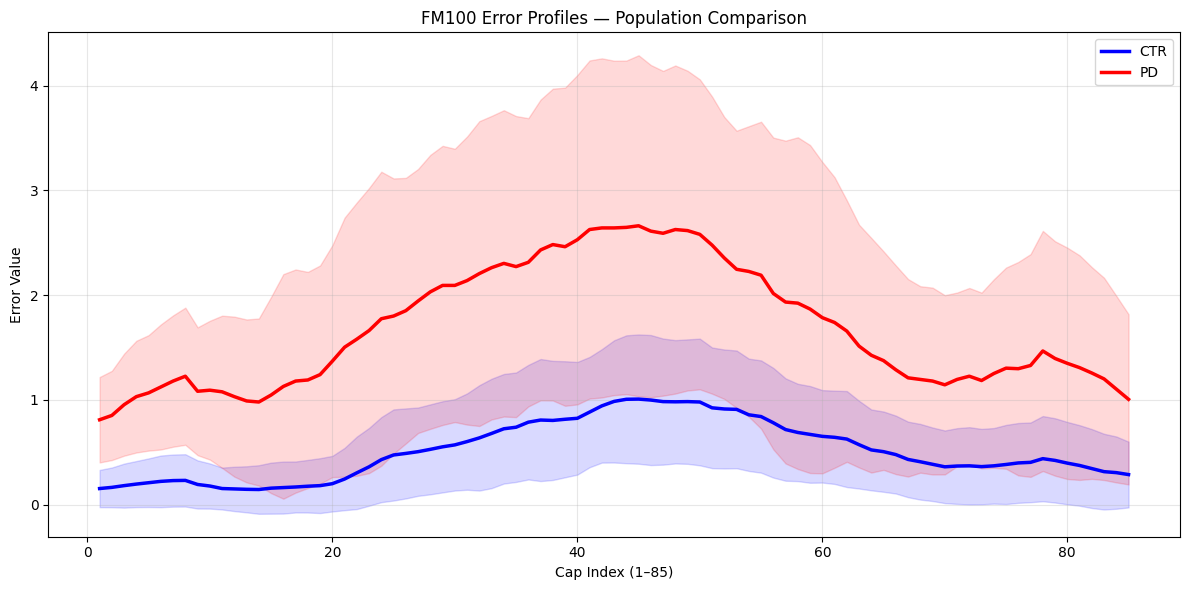

In [19]:
plot_population_comparison(FM100, info_PDCTR, smooth=True, window=15)
plot_population_comparison_shading(FM100, info_PDCTR, smooth=True, window=15)


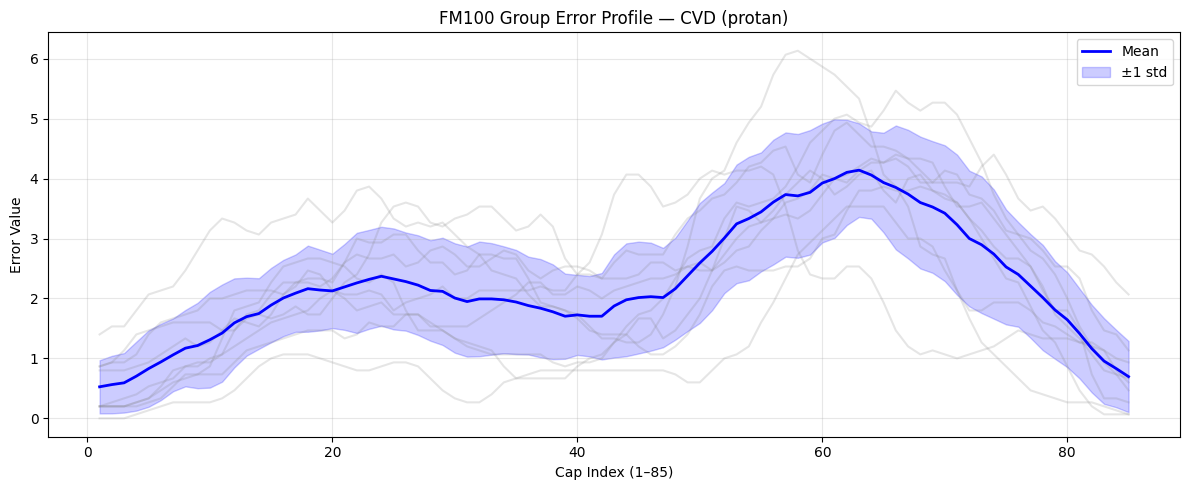

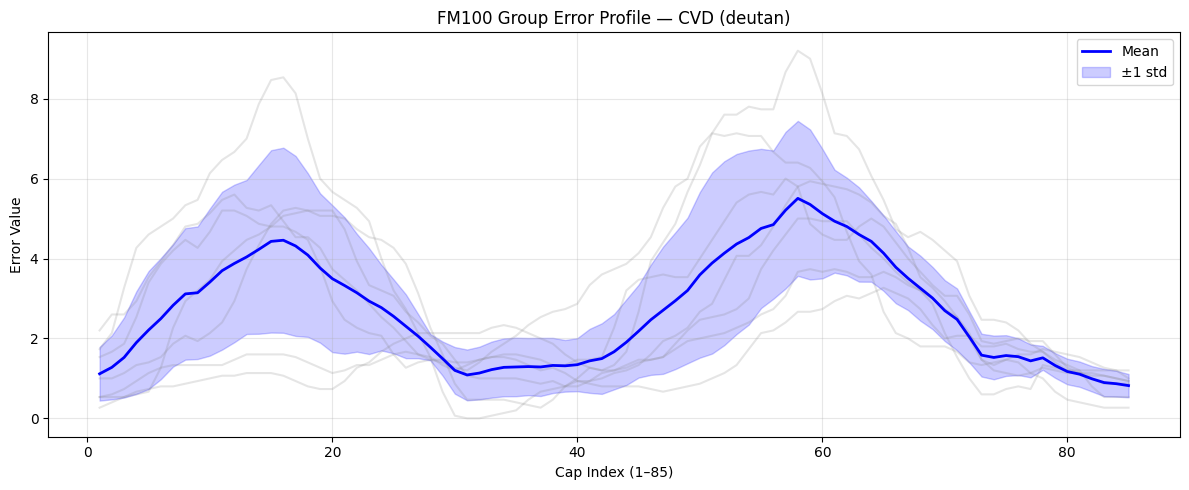

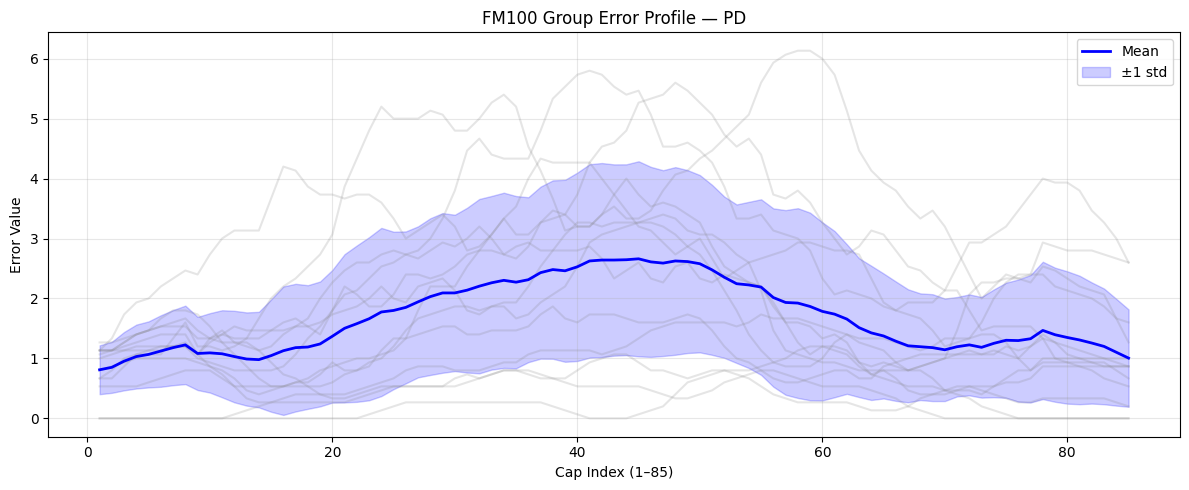

In [ ]:
from metamers.scores.FM100 import load_FM100_raw, load_participant_info
from metamers.scores.plotting import plot_group_errors

FM100 = load_FM100_raw()
info  = load_participant_info()
info_PDCTR = info[info["Group"].isin(["CTR", "PD"])]
plot_group_errors(FM100, info, group_name="CVD", subgroup_name="protan", smooth=True, window=15, show_individuals=True)
plot_group_errors(FM100, info, group_name="CVD", subgroup_name="deutan", smooth=True, window=15, show_individuals=True)

plot_group_errors(FM100, info, group_name="PD", smooth=True, window=15, show_individuals=True)




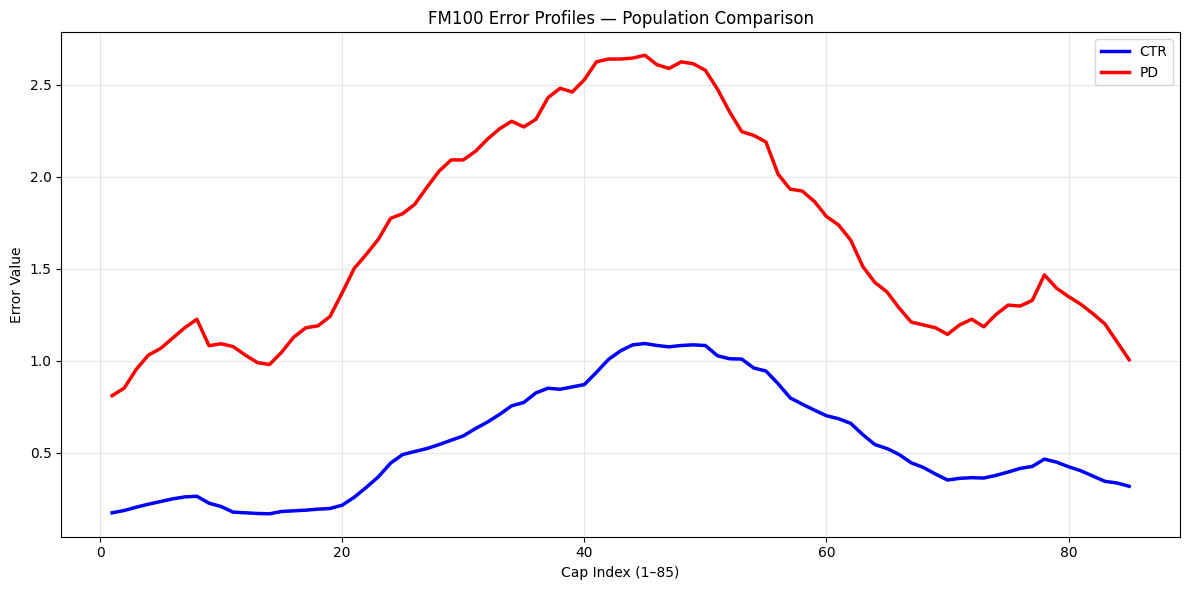

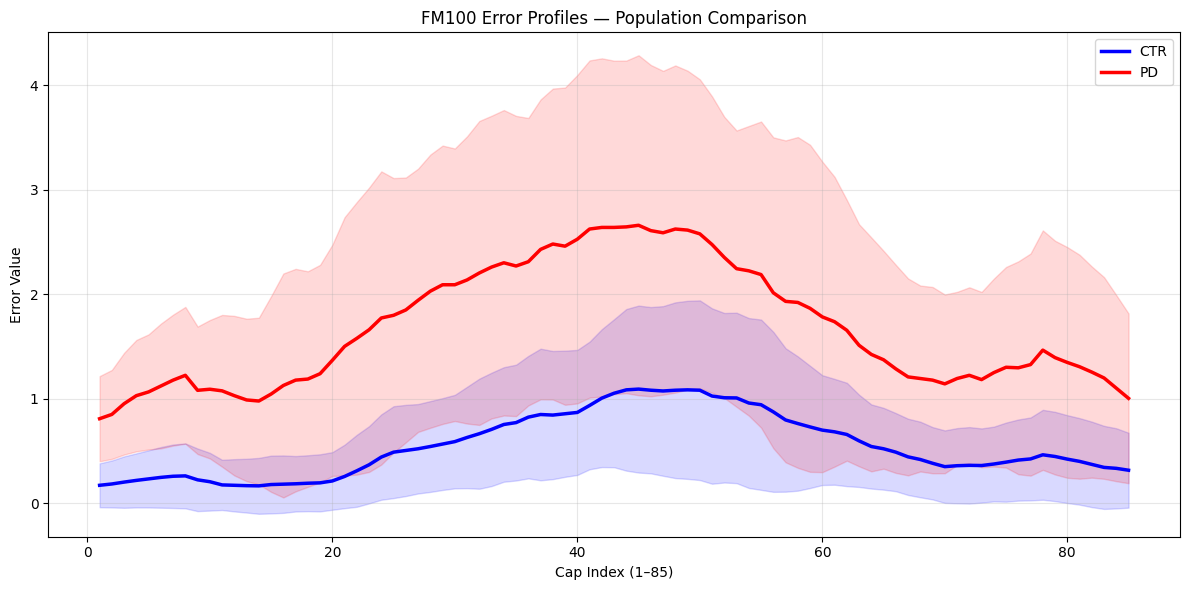

In [13]:
from metamers.scores.FM100 import load_FM100_raw, load_participant_info
from metamers.scores.plotting import plot_population_comparison, plot_population_comparison_shading

FM100 = load_FM100_raw()
info_PDCTR = info[info["Group"].isin(["CTR", "PD"])]

plot_population_comparison(FM100, info_PDCTR, smooth=True, window=15)
plot_population_comparison_shading(FM100, info_PDCTR, smooth=True, window=15)


In [ ]:
from metamers.scores.FM100 import load_FM100_raw, load_participant_info
from metamers.scores.plotting import plot_population_comparison, plot_population_comparison_shading

FM100 = load_FM100_raw()
info  = load_participant_info()

plot_population_comparison(FM100, info, smooth=True, window=15)
plot_population_comparison_shading(FM100, info, smooth=True, window=15)
